# 06 — Task 3: Holdout evaluation + final submission

Evaluate the tuned model once on the held-out split, then refit on all training data and write the Task 3 submission.

## 0. Setup

Imports, src helpers, paths.

In [1]:
# Adds project root to path so `import src...` works from notebooks/.
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import json
import joblib

from sklearn.base import clone
from sklearn.model_selection import cross_val_predict

from src import paths, data, evaluation
from src.paths import FIGURES
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. Load features, locked split, and tuned model

In [2]:
X, y, ids = data.load_train_features()
Xt, test_ids = data.load_test_features()
holdout_idx = np.load(paths.DATA_PROCESSED / 'holdout_idx.npy')
dev_idx = np.load(paths.DATA_PROCESSED / 'dev_idx.npy')
cv = evaluation.make_cv()

best = joblib.load(paths.MODELS / 'best_lightgbm_tuned.pkl')
with open(paths.MODELS / 'best_lightgbm_tuned.json') as f:
    tuned_meta = json.load(f)

print(f"Loaded {type(best).__name__}, fit on dev_idx only ({len(y) - len(holdout_idx)} rows)")
print(f"CV mean F1 from 05_tuning: {tuned_meta['cv_mean_f1']:.4f} "
      f"(std {tuned_meta['cv_std_f1']:.4f}, {tuned_meta['n_stage1_trials'] + tuned_meta['n_stage2_trials']} trials)")
print("Winning params:", tuned_meta["params"])

Loaded LGBMClassifier, fit on dev_idx only (16000 rows)
CV mean F1 from 05_tuning: 0.7443 (std 0.0044, 26 trials)
Winning params: {'colsample_bytree': 0.5198042692950159, 'min_child_samples': 7, 'n_estimators': 456, 'reg_alpha': 0.34104824737458306, 'reg_lambda': 0.13010318597055903, 'learning_rate': 0.034494, 'num_leaves': 149}


## 2. Tune the decision threshold

`class_weight="balanced"` only reshapes the *training loss*; it doesn't guarantee the
resulting probability model's default 0.5 cutoff is Macro-F1-optimal. Sweep candidate
thresholds against honest out-of-fold CV probabilities on `dev_idx` (leakage-free, same
standard as the hyperparameter search) and pick the one that maximizes Macro F1.

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


CV Macro F1 @ default threshold (0.5): 0.7443
CV Macro F1 @ tuned threshold (0.525): 0.7462
Gain from threshold tuning (CV, dev_idx): +0.0019


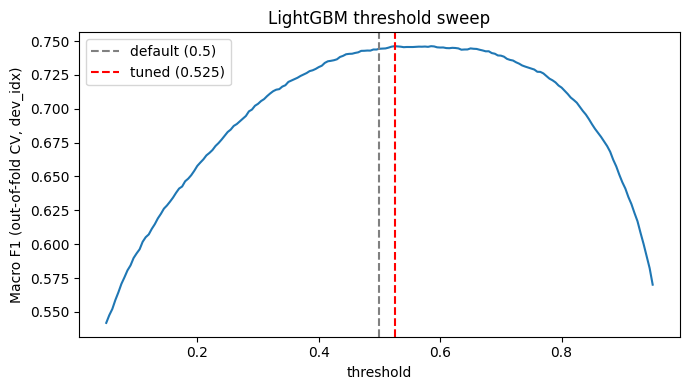

In [3]:
# Out-of-fold probabilities on dev_idx - each sample's probability comes from a model
# that never saw it during that fold's training (clone() re-fits fresh per fold), same
# leakage-free standard as the CV score used for hyperparameter tuning. No retraining
# beyond the 5 fold-fits cross_val_predict already needs to do this properly.
oof_proba = cross_val_predict(
    clone(best), X[dev_idx], y[dev_idx], cv=cv, method="predict_proba",
)[:, 1]

thresholds = np.linspace(0.05, 0.95, 181)
f1_by_threshold = np.array([
    evaluation.macro_f1(y[dev_idx], (oof_proba >= t).astype(int)) for t in thresholds
])
best_threshold = float(thresholds[int(np.argmax(f1_by_threshold))])
cv_f1_at_threshold = float(f1_by_threshold.max())
cv_f1_default_threshold = evaluation.macro_f1(y[dev_idx], (oof_proba >= 0.5).astype(int))

print(f"CV Macro F1 @ default threshold (0.5): {cv_f1_default_threshold:.4f}")
print(f"CV Macro F1 @ tuned threshold ({best_threshold:.3f}): {cv_f1_at_threshold:.4f}")
print(f"Gain from threshold tuning (CV, dev_idx): {cv_f1_at_threshold - cv_f1_default_threshold:+.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(thresholds, f1_by_threshold)
ax.axvline(0.5, color="grey", linestyle="--", label="default (0.5)")
ax.axvline(best_threshold, color="red", linestyle="--", label=f"tuned ({best_threshold:.3f})")
ax.set_xlabel("threshold")
ax.set_ylabel("Macro F1 (out-of-fold CV, dev_idx)")
ax.set_title("LightGBM threshold sweep")
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "lightgbm_threshold_sweep.png", dpi=120)
plt.show()

## 3. Holdout Macro F1 (default vs tuned threshold)

In [4]:
holdout_proba = best.predict_proba(X[holdout_idx])[:, 1]
holdout_f1_default = evaluation.macro_f1(y[holdout_idx], (holdout_proba >= 0.5).astype(int))
holdout_f1_tuned = evaluation.macro_f1(y[holdout_idx], (holdout_proba >= best_threshold).astype(int))

cv_f1 = tuned_meta["cv_mean_f1"]  # from 05_tuning, default threshold
gap = cv_f1 - holdout_f1_default  # unchanged definition, comparable to the recorded Kaggle score
threshold_gain_holdout = holdout_f1_tuned - holdout_f1_default

print(f"Holdout Macro F1 @ default threshold (0.5): {holdout_f1_default:.4f}")
print(f"Holdout Macro F1 @ tuned threshold ({best_threshold:.3f}): {holdout_f1_tuned:.4f}")
print(f"Threshold-tuning gain on holdout: {threshold_gain_holdout:+.4f}")
print(f"\nCV mean F1 (05_tuning, default threshold): {cv_f1:.4f}")
print(f"Gap (CV @ default - holdout @ default): {gap:+.4f}")

# The holdout set was never touched during tuning (hyperparameters or threshold), so
# holdout_f1_tuned is the one honest check that the chosen threshold isn't overfit to
# the dev_idx CV sweep above. It does NOT predict the Kaggle score, since the brief
# documents a separate train-to-test distribution shift a same-distribution holdout
# split can't catch.
#
# Ledger-safe write: replace this model's row if it already exists rather than
# overwriting other models' rows - holdout_metrics.csv accumulates one row per model
# (e.g. logreg_ridge from 06b_holdout_logreg_ridge.ipynb), same spirit as
# baseline_results.csv.
metrics_path = paths.DATA_PROCESSED / "holdout_metrics.csv"
new_row = pd.DataFrame([{
    "model": "lightgbm",
    "cv_mean_f1": cv_f1,
    "holdout_f1": holdout_f1_default,
    "gap": gap,
    "threshold": best_threshold,
    "cv_f1_at_threshold": cv_f1_at_threshold,
    "holdout_f1_at_threshold": holdout_f1_tuned,
    "threshold_gain_holdout": threshold_gain_holdout,
}])
if metrics_path.exists():
    existing = pd.read_csv(metrics_path)
    existing = existing[existing["model"] != "lightgbm"]
    holdout_metrics = pd.concat([existing, new_row], ignore_index=True)
else:
    holdout_metrics = new_row
holdout_metrics.to_csv(metrics_path, index=False)
print("\n", holdout_metrics.to_string(index=False))

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Holdout Macro F1 @ default threshold (0.5): 0.7437
Holdout Macro F1 @ tuned threshold (0.525): 0.7468
Threshold-tuning gain on holdout: +0.0031

CV mean F1 (05_tuning, default threshold): 0.7443
Gap (CV @ default - holdout @ default): +0.0006

        model  cv_mean_f1  holdout_f1       gap  threshold  cv_f1_at_threshold  holdout_f1_at_threshold  threshold_gain_holdout
logreg_ridge    0.727866    0.739153 -0.011287        NaN                 NaN                      NaN                     NaN
    lightgbm    0.744273    0.743691  0.000582      0.525            0.746203                 0.746767                0.003076


## 4. Refit on full train + write Task 3 submission

In [5]:
# Refit on ALL labeled data (dev_idx + holdout_idx combined), not just dev_idx - the
# holdout split's only job was the honest check above; keeping the final submission
# model restricted to 80% of the labeled data would waste real signal for no reason.
best.fit(X, y)

# Save the full-refit model separately from best_lightgbm_tuned.pkl (which stays as the
# dev-only-fit artifact from 05_tuning.ipynb) so it's unambiguous which one made the
# submission.
joblib.dump(best, paths.MODELS / "final_lightgbm_full_refit.pkl")

# Uses the tuned threshold from section 2, not the default 0.5.
test_proba = best.predict_proba(Xt)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)
data.write_submission(test_ids, test_preds, "final_task3.csv")

pred_balance = pd.Series(test_preds).value_counts(normalize=True).round(4).to_dict()
print(f"Wrote submissions/final_task3.csv - {len(test_preds)} predictions "
      f"(threshold={best_threshold:.3f})")
print(f"Predicted class balance: {pred_balance}")
print(f"(train class balance was: "
      f"{pd.Series(y).value_counts(normalize=True).round(4).to_dict()})")
print(f"\nIMPORTANT: this file's content changed from what scored 0.65738 on Kaggle "
      f"(that score used the default 0.5 threshold). Re-upload to get an updated score "
      f"- the old score no longer reflects this file.")

C:\Users\Cliffton\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Wrote submissions/final_task3.csv - 6999 predictions (threshold=0.525)
Predicted class balance: {1: 0.7338, 0: 0.2662}
(train class balance was: {1: 0.6252, 0: 0.3748})

IMPORTANT: this file's content changed from what scored 0.65738 on Kaggle (that score used the default 0.5 threshold). Re-upload to get an updated score - the old score no longer reflects this file.


## Discussion / carry-forward -> `SUBMISSION.ipynb` + Task 4 report

**Holdout check:** Macro F1 0.7437 @ default threshold on the never-touched holdout
split, versus 0.7443 from 05_tuning's CV estimate - a gap of only +0.0006. The tuned
LightGBM config is not overfit to the CV search.

**Threshold tuning: modest gain, not a dramatic lever here.** Sweeping thresholds
against out-of-fold CV probabilities on `dev_idx` found 0.525 as Macro-F1-optimal
(barely above the default 0.5), improving holdout F1 by +0.0031 (0.7437 -> 0.7468).
Class-weighted training loss already does a fair amount of implicit calibration; with
a comparatively mild 62.5/37.5 imbalance (not the more extreme skews where threshold
placement typically matters most), there's less left for a post-hoc cutoff to fix.

**Class balance shift, and a hypothesis that turned out wrong:** the submission
predicts machine/human proportions shifted from training - originally 74.95%/25.05% at
the default threshold, now 73.38%/26.62% after threshold tuning (a small correction,
consistent with the modest gain above). This notebook originally speculated the shift
might be concentrated in the 5000 numeric-format ids versus the 1999 UUID-format ids,
hypothesizing that split corresponded to the public/private leaderboard partition.
**That hypothesis is very likely wrong:** Kaggle's own disclosed rule is that the
public leaderboard uses ~51% of the test data with the other 49% held for final
standings - a roughly even split that doesn't match the observed 28.6%/71.4%
id-format ratio. Treat the id-format observation as an unconfirmed, now-doubtful side
note, not a working hypothesis.

**Kaggle result: 0.65738 Macro F1** (at the default 0.5 threshold), versus 0.7437
holdout - a gap of 0.0863. The holdout check already ruled out CV overfitting as the
cause, so this points to the brief's documented train-to-test distribution shift.
Comparison model `logreg_ridge` (see `06b_holdout_logreg_ridge.ipynb`) shows a
meaningfully smaller gap (0.0523) on the same real leaderboard, and actually
*outscores* LightGBM there (0.68681 vs 0.65738) despite scoring lower on CV/holdout -
evidence the shift affects gradient boosting more than a linear model on this dataset.

**`submissions/final_task3.csv` has been regenerated with the tuned threshold (0.525)**
and no longer reflects the 0.65738 score - that score was for the default-threshold
version. Re-upload to Kaggle to see whether the +0.0031 holdout gain from threshold
tuning survives the same train-to-test shift that hurt the rest of the model, or gets
swamped by it like everything else has. This is the tuned LightGBM refit on all
labeled data (dev + holdout), saved separately as `models/final_lightgbm_full_refit.pkl`
from the dev-only-fit `best_lightgbm_tuned.pkl`. Given `logreg_ridge_task3.csv`
currently scores higher on the public leaderboard (pre-threshold-tuning), worth
deciding which submission(s) to mark as final on Kaggle once both are re-scored.